Import the library.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

Read the data.

In [5]:
df = pd.read_csv('Datasets/concrete_data.csv')
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
475,446.0,24.0,79.0,162.0,11.6,967.0,712.0,3,35.36
132,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.30
502,491.0,26.0,123.0,210.0,3.9,882.0,699.0,7,33.49
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28,68.30


Find the shape of the data.

In [6]:
df.shape

(1030, 9)

Find missing/null values in data.

In [7]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

Split the data into train test.

In [8]:
x = df.drop(columns=['Strength'])
y = df.iloc[:,-1]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Train the model by using Linear Regression.

In [9]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.627553179231485

Find the cross validation score.

In [10]:
np.mean(cross_val_score(lr,x,y,scoring='r2',cv=5))

np.float64(0.46099404916628606)

Plot the graphs and QQ plot to find the extend of normal split of data.

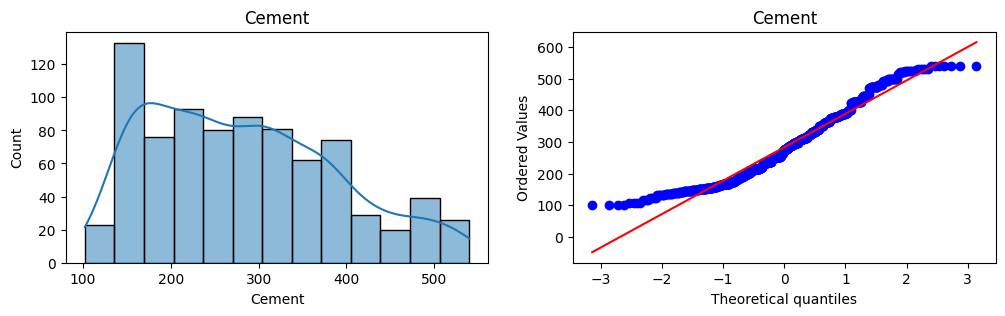

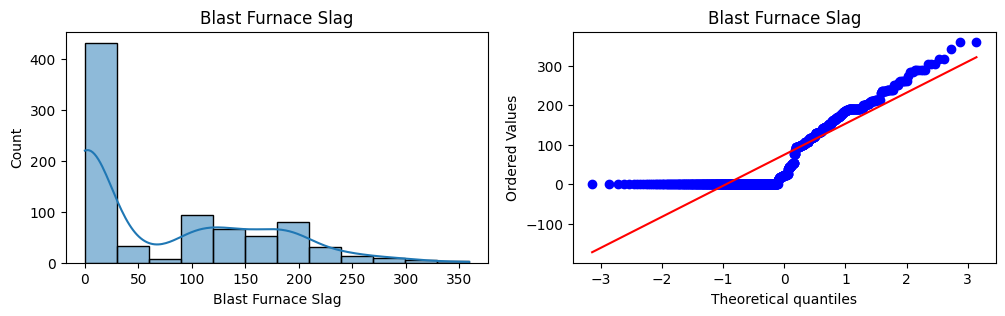

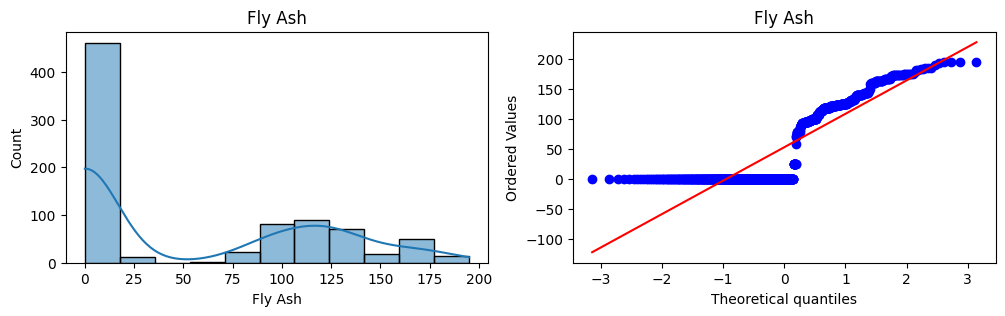

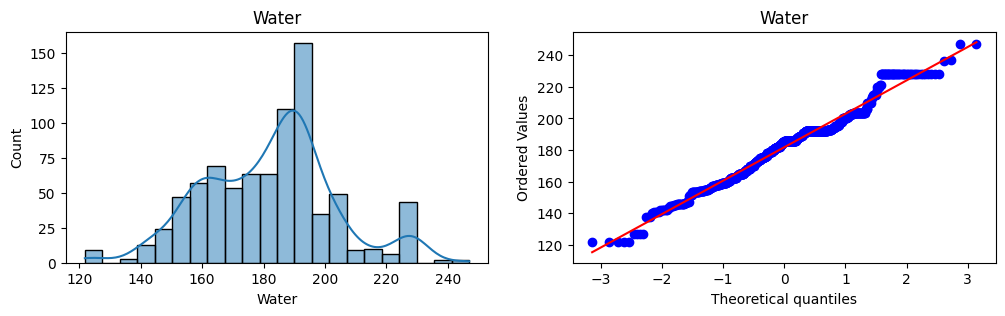

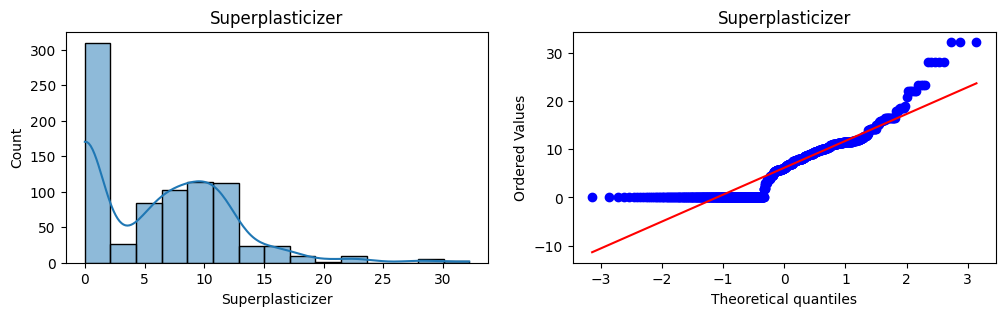

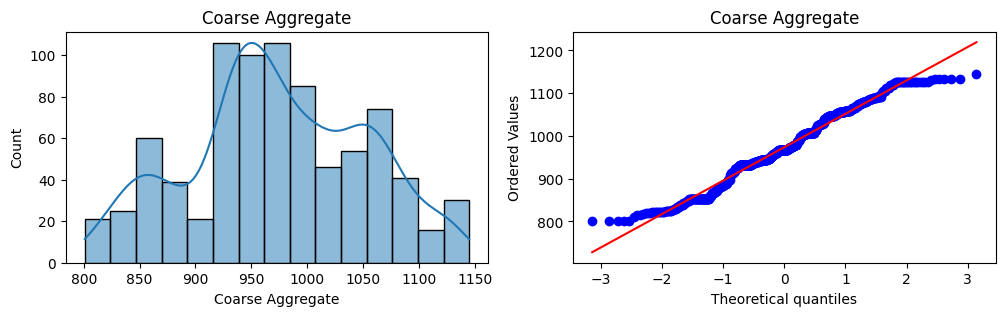

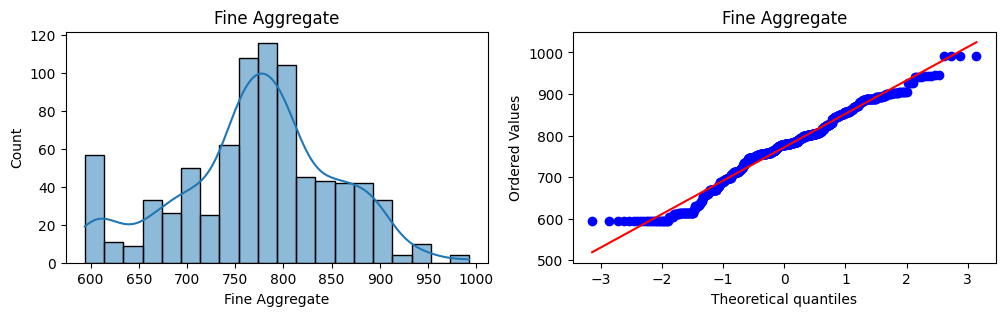

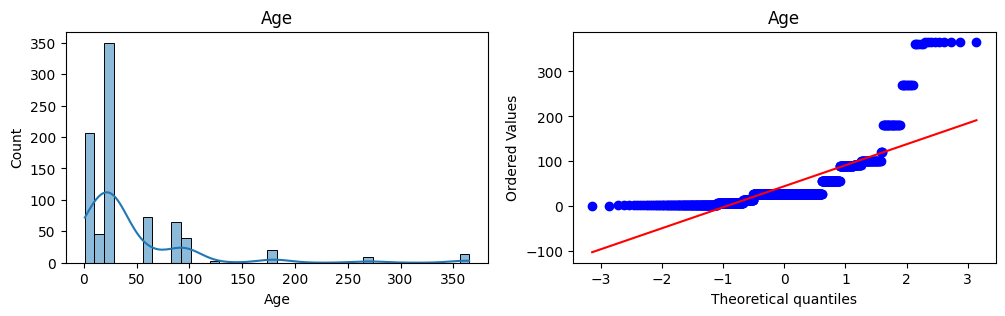

In [11]:
for col in x_train.columns:
    plt.figure(figsize=(12,3))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

Use power tranformer (box-cox) to make the data normal.

In [12]:
pt = PowerTransformer(method='box-cox')

x_train_tnf = pt.fit_transform(x_train+0.000000001)
x_test_tnf = pt.transform(x_test+0.000000001)

pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.019115
2,Fly Ash,-0.028337
3,Water,0.772682
4,Superplasticizer,0.070353
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


Train the transformed data.

In [13]:
lr = LinearRegression()
lr.fit(x_train_tnf,y_train)
y_pred = lr.predict(x_test_tnf)
r2_score(y_test,y_pred)

0.8034834015922221

Find the cross validation score.

In [14]:
x_tnf = pt.fit_transform(x+0.000000001)
np.mean(cross_val_score(lr,x_tnf,y,scoring='r2',cv=5))

np.float64(0.6651894390888445)

Plot the graphs of tranformed data.

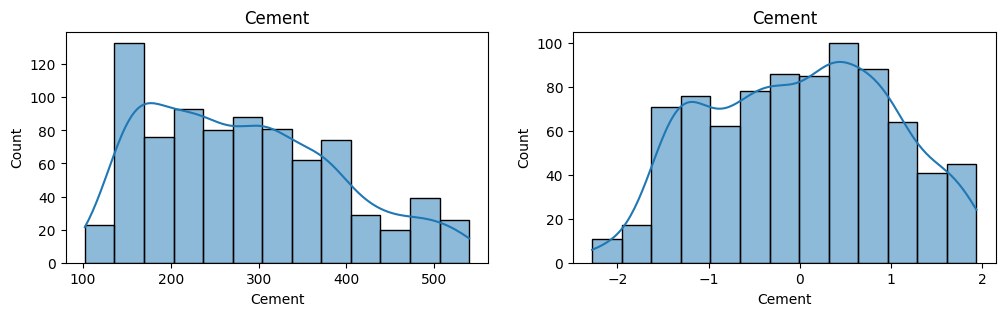

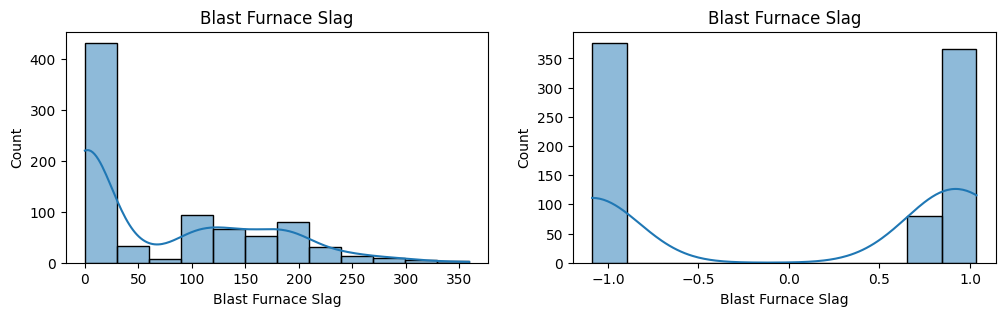

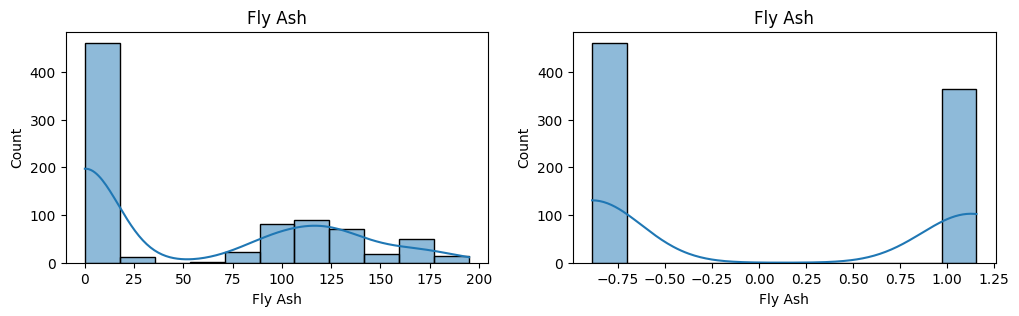

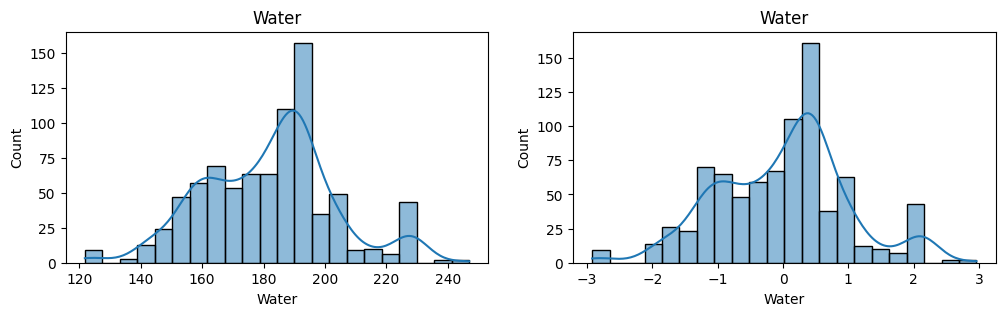

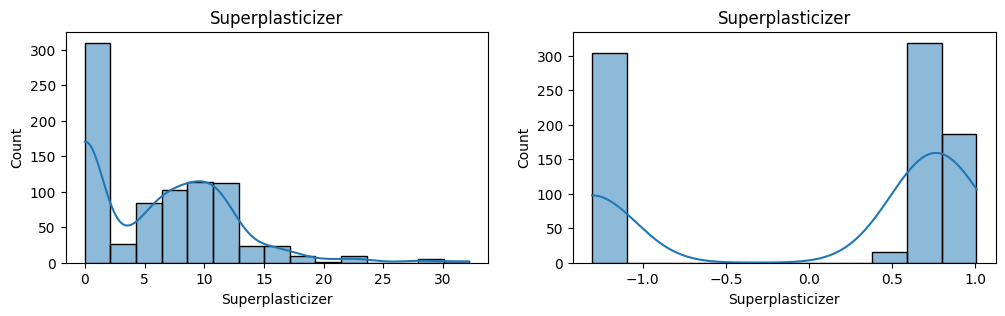

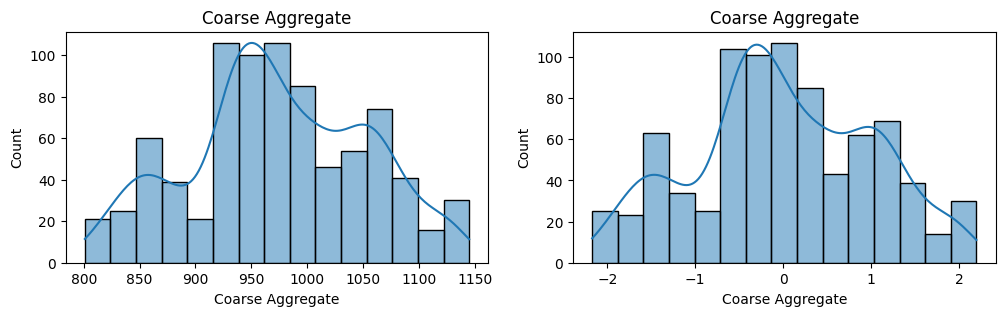

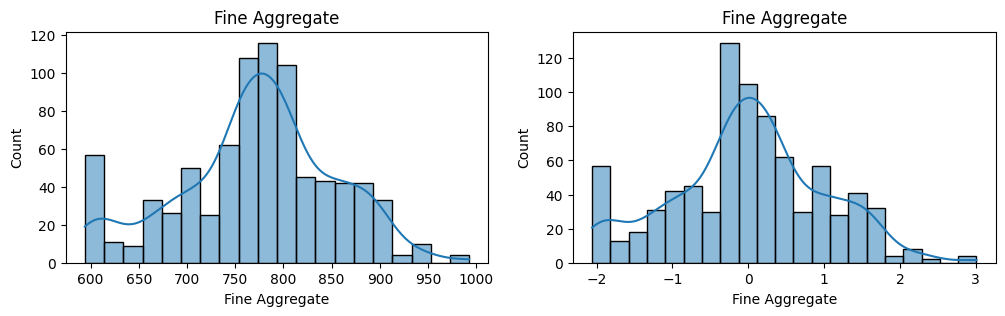

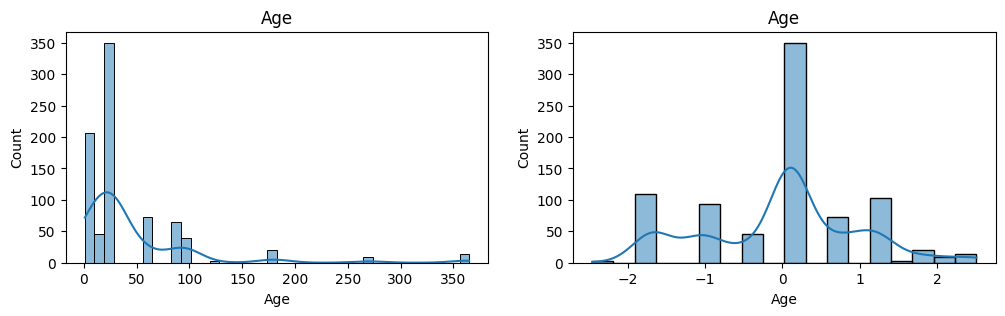

In [18]:
x_train_tnf = pd.DataFrame(x_train_tnf,columns=x_train.columns)

for col in x_train_tnf.columns:
    plt.figure(figsize=(12,3))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_tnf[col],kde=True)
    plt.title(col)

    plt.show()

Use power tranformer (Yeo - johnson ) on the datand finding the lambda.

In [19]:
pt2 = PowerTransformer() 
x_train_tnf2 = pt2.fit_transform(x_train+0.000000001)
x_test_tnf2 = pt2.transform(x_test+0.000000001)   

lr = LinearRegression()
lr.fit(x_train_tnf2,y_train)
y_pred = lr.predict(x_test_tnf2)
r2_score(y_test,y_pred) 

0.8161906519458565

In [20]:
pd.DataFrame({'cols':x_train.columns,'yeo_johnson_lambdas':pt.lambdas_})

,cols,yeo_johnson_lambdas
0,Cement,0.172271
1,Blast Furnace Slag,0.019240
2,Fly Ash,-0.023552
3,Water,0.809568
4,Superplasticizer,0.070951
5,Coarse Aggregate,1.129168
6,Fine Aggregate,1.829625
7,Age,0.048975


Find the cross validation score.

In [ ]:
x_tnf2 = pt.fit_transform(x+0.000000001)
np.mean(cross_val_score(lr,x_tnf2,y,scoring='r2',cv=5))

np.float64(0.68346251471382)

Comparision of lambda of box-cox and yeo-johnson transformers.

In [ ]:

pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt2.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830764,1.783100
7,Age,0.001771,0.019885
